1. Импорты и загрузка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

2. Загрузка данных

In [3]:
path = "winequality-red.csv"

# В этом CSV разделитель — точка с запятой
df = pd.read_csv(path, sep=';')

print("Размер датасета:", df.shape)

display(df.head())

print("\nНазвания столбцов:")
print(df.columns.tolist())

Размер датасета: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Названия столбцов:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


 3. Общая информация о данных

In [4]:
df.info()

# Основные статистические характеристики
display(df.describe().T)

# Проверяем пропуски
print("Количество пропусков:")
print(df.isna().sum())

# Проверяем дубликаты
print("Количество дубликатов:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Количество пропусков:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Количество дубликатов: 240


4. Распределение исходного quality

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


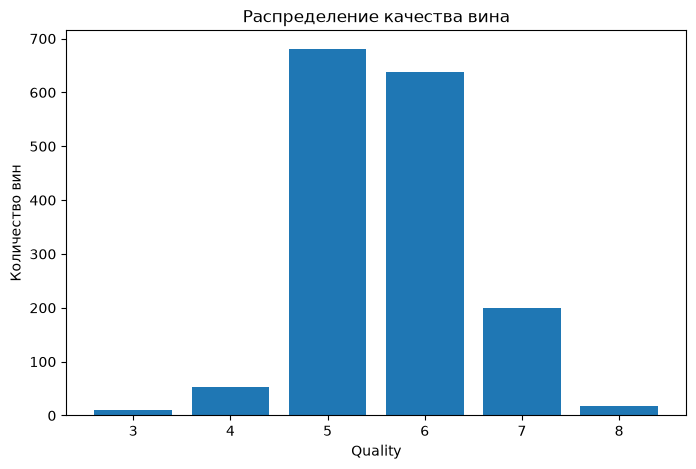

In [5]:
quality_counts = df['quality'].value_counts().sort_index()

print(quality_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.xlabel('Quality')
plt.ylabel('Количество вин')
plt.title('Распределение качества вина')

plt.show()

5. Распределения признаков

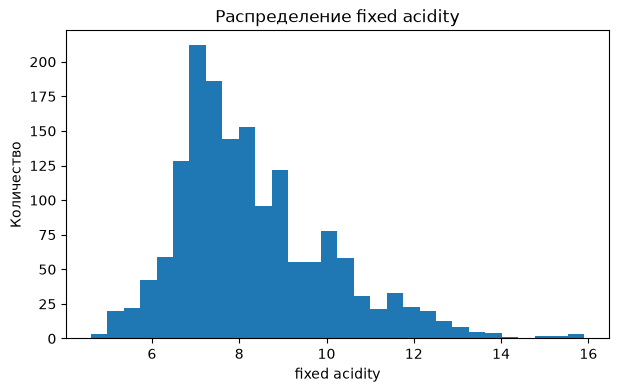

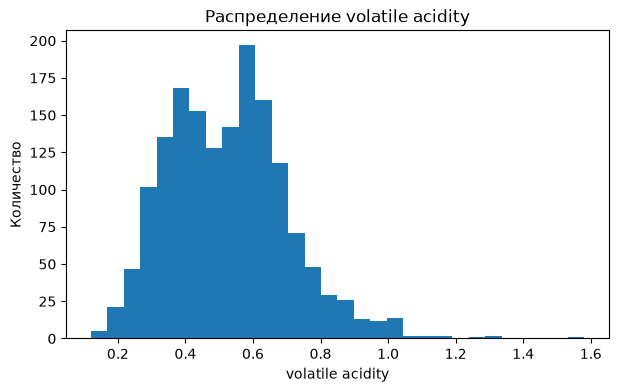

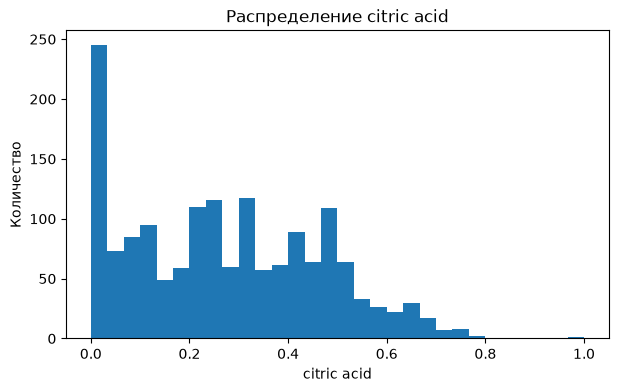

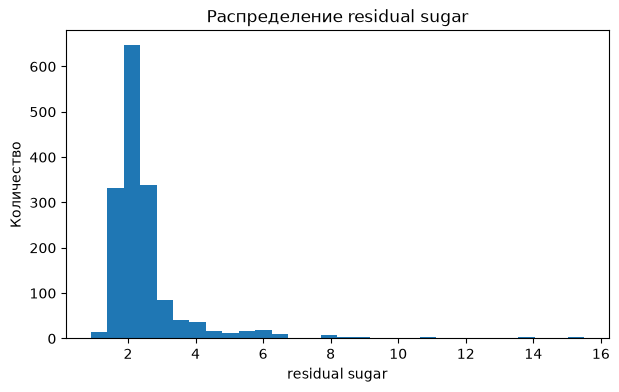

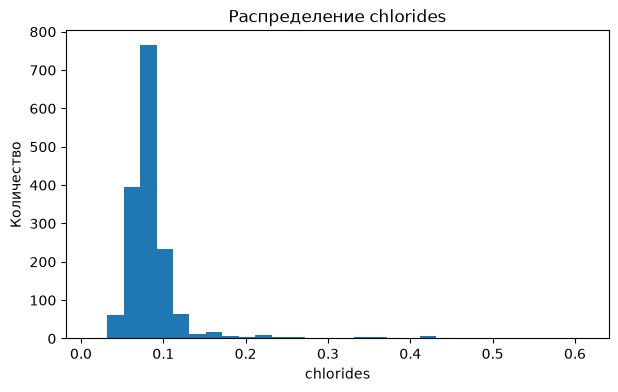

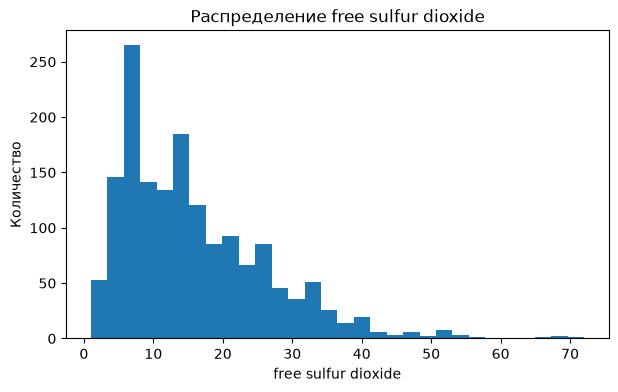

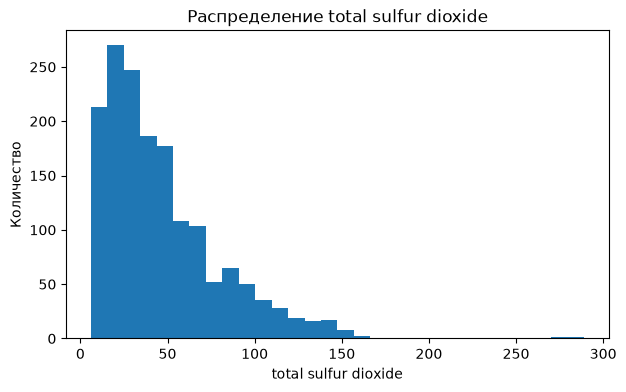

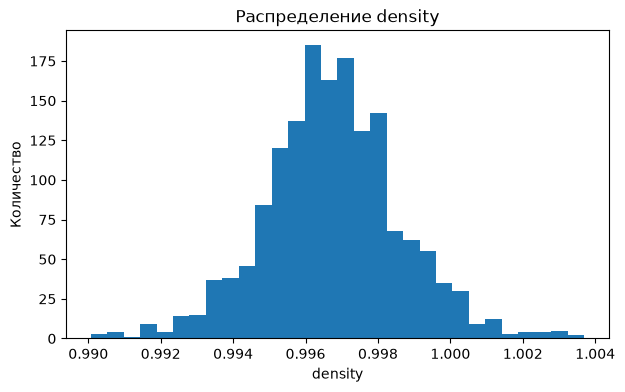

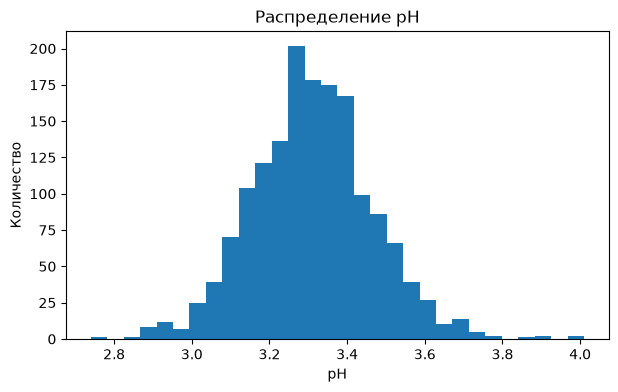

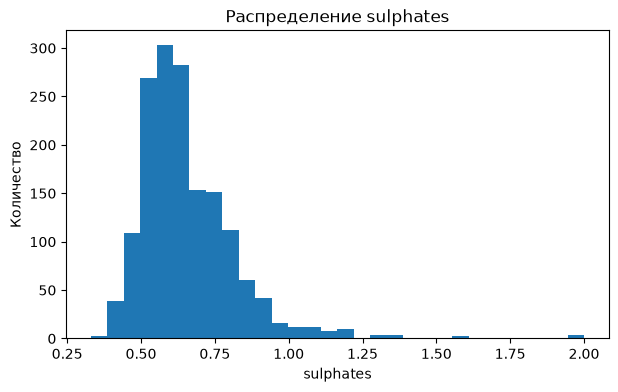

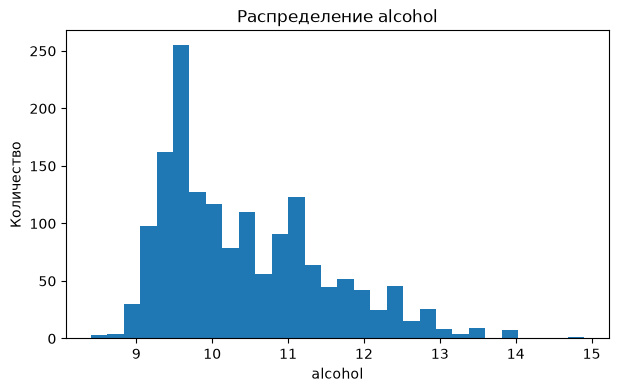

In [7]:
features = df.drop(columns='quality').columns

for column in features:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column],
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.title(f'Распределение {column}')

    plt.show()

6. Корреляция признаков с quality

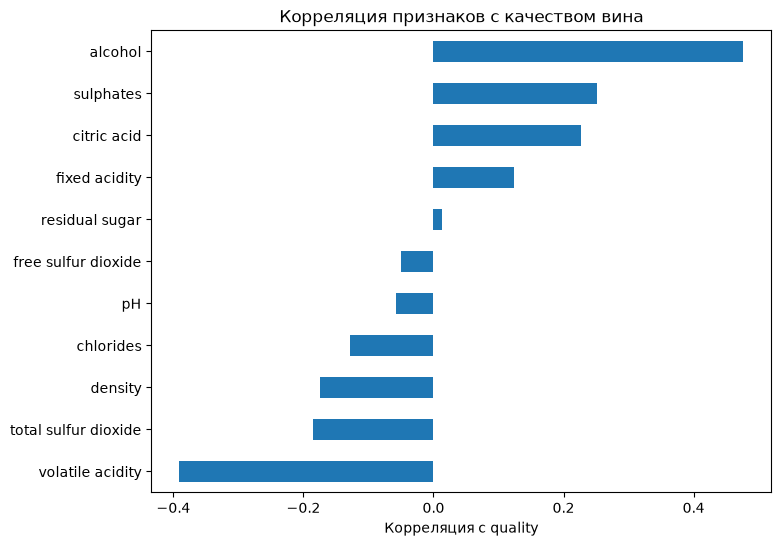

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [9]:
correlation = (
    df.corr(numeric_only=True)['quality']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

correlation.drop('quality').sort_values().plot(
    kind='barh'
)

plt.xlabel('Корреляция с quality')
plt.title('Корреляция признаков с качеством вина')

plt.show()

display(correlation)

7. Создаем бинарную целевую переменную

In [10]:
df['wine_quality'] = np.where(
    df['quality'] < 6.5,
    'bad wine',
    'good wine'
)

display(
    df[['quality', 'wine_quality']].head(10)
)

,quality,wine_quality
0,5,bad wine
1,5,bad wine
2,5,bad wine
3,6,bad wine
4,5,bad wine
5,5,bad wine
6,5,bad wine
7,7,good wine
8,7,good wine
9,5,bad wine


In [11]:
#Посмотрим распределение классов:
print(
    df['wine_quality'].value_counts()
)

print()

print(
    df['wine_quality'].value_counts(normalize=True)
)

wine_quality
bad wine     1382
good wine     217
Name: count, dtype: int64

wine_quality
bad wine     0.86429
good wine    0.13571
Name: proportion, dtype: float64


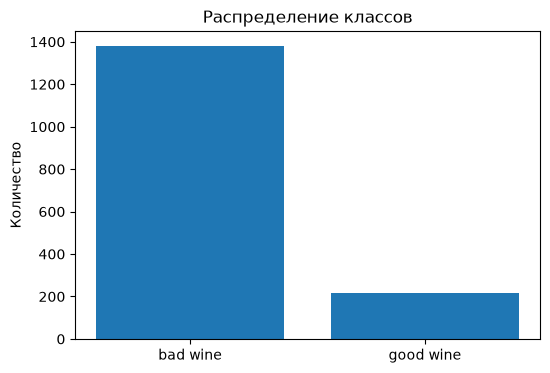

In [12]:
#График:
class_counts = df['wine_quality'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.ylabel('Количество')
plt.title('Распределение классов')

plt.show()

8. Кодирование Target

In [13]:
df['target'] = df['wine_quality'].map({
    'bad wine': 0,
    'good wine': 1
})

display(
    df[['quality', 'wine_quality', 'target']].head(10)
)

,quality,wine_quality,target
0,5,bad wine,0
1,5,bad wine,0
2,5,bad wine,0
3,6,bad wine,0
4,5,bad wine,0
5,5,bad wine,0
6,5,bad wine,0
7,7,good wine,1
8,7,good wine,1
9,5,bad wine,0


9. Формируем x и y

In [14]:
X = df.drop(
    columns=[
        'quality',
        'wine_quality',
        'target'
    ]
)

y = df['target']

print("Размер X:", X.shape)
print("Размер y:", y.shape)

display(X.head())

Размер X: (1599, 11)
Размер y: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


10. Train/test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1279, 11)
Test: (320, 11)


11. Pipeline

In [18]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# Сетка гиперпараметров
param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100]
    },
    {
        'svc__kernel': ['rbf', 'poly', 'sigmoid'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']
    }
]

# Подбор параметров
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучший accuracy:")
print(grid_search.best_score_)

Лучшие параметры:
{'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'}

Лучший accuracy:
0.8967830882352942


13. STRATIFIED K-FOLD

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

 14. Подбор гиперпараметров

In [20]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 76 candidates, totalling 380 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid=[{'svc__C': [0.1, 1, 10, 100],
                          'svc__kernel': ['linear']},
                         {'svc__C': [0.1, 1, 10, 100],
                          'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
                          'svc__kernel': ['rbf', 'poly', 'sigmoid']}],
             scoring='accuracy', verbose=1)

15. Лучшая модель

In [21]:
print(
    "Лучшие параметры:"
)

print(
    grid_search.best_params_
)

print(
    "\nЛучший accuracy на кросс-валидации:"
)

print(
    grid_search.best_score_
)

Лучшие параметры:
{'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'}

Лучший accuracy на кросс-валидации:
0.8912959558823529


16. Test score

In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy на test:",
    test_accuracy
)

Accuracy на test: 0.921875


17. CONFUSION MATRIX

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[274   3]
 [ 22  21]]


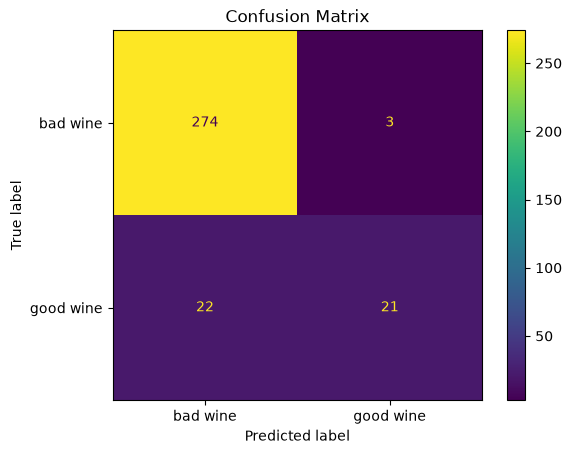

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'bad wine',
        'good wine'
    ]
)

disp.plot()

plt.title(
    'Confusion Matrix'
)

plt.show()

18. CLASSIFICATION REPORT

In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'bad wine',
            'good wine'
        ]
    )
)

              precision    recall  f1-score   support

    bad wine       0.93      0.99      0.96       277
   good wine       0.88      0.49      0.63        43

    accuracy                           0.92       320
   macro avg       0.90      0.74      0.79       320
weighted avg       0.92      0.92      0.91       320



19. CROSS-VALIDATION лучшей модели

In [27]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

print(
    "Accuracy на каждом фолде:"
)

print(
    cv_scores
)

print(
    "\nСредний accuracy:"
)

print(
    cv_scores.mean()
)

print(
    "\nСтандартное отклонение:"
)

print(
    cv_scores.std()
)

print("Лучшие параметры:", grid_search.best_params_)
print("Accuracy на кросс-валидации:", grid_search.best_score_)
print("Accuracy на тестовой выборке:", test_accuracy)

Accuracy на каждом фолде:
[0.90625    0.89375    0.921875   0.9        0.90282132]

Средний accuracy:
0.9049392633228839

Стандартное отклонение:
0.009408707047994055
Лучшие параметры: {'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'}
Accuracy на кросс-валидации: 0.8912959558823529
Accuracy на тестовой выборке: 0.921875


Вывод:
В ходе работы был проведён первичный анализ датасета красных вин, изучены распределения признаков и их связь с целевой переменной quality. Исходная целевая переменная была преобразована в бинарную: вина с quality < 6.5 отнесены к классу bad wine, а с quality > 6.5 — к классу good wine.
Для классификации была использована модель SVC. Признаки были стандартизированы с помощью StandardScaler. С помощью GridSearchCV были перебраны различные значения гиперпараметров C, gamma и типы ядра linear, poly, rbf, sigmoid.
Лучшие параметры модели:
'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'
Лучшее значение accuracy на кросс-валидации:
0.8912959558823529
Accuracy на тестовой выборке:
0.921875
Таким образом, подбор гиперпараметров позволил выбрать наиболее подходящую конфигурацию SVM для классификации качества вина. Результаты на тестовой выборке показывают, насколько хорошо выбранная модель обобщается на новых данных.